In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset Shape:", X.shape)
print("Classes:", data.target_names)

Dataset Shape: (569, 30)
Classes: ['malignant' 'benign']


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, knn_pred))

print(classification_report(y_test, knn_pred))

KNN Accuracy: 0.9473684210526315
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



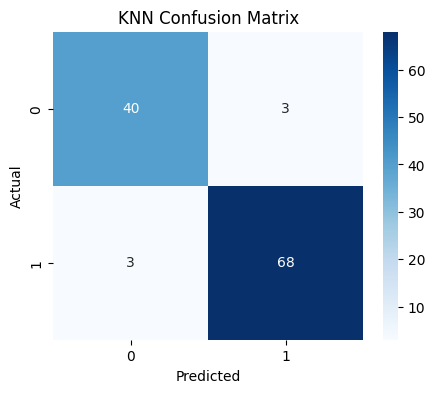

In [6]:
cm = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [7]:
svm_linear = SVC(kernel="linear")

svm_linear.fit(X_train_scaled, y_train)

svm_pred = svm_linear.predict(X_test_scaled)

print("Linear SVM Accuracy:",
      accuracy_score(y_test, svm_pred))

print(classification_report(y_test, svm_pred))

Linear SVM Accuracy: 0.956140350877193
              precision    recall  f1-score   support

           0       0.93      0.95      0.94        43
           1       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



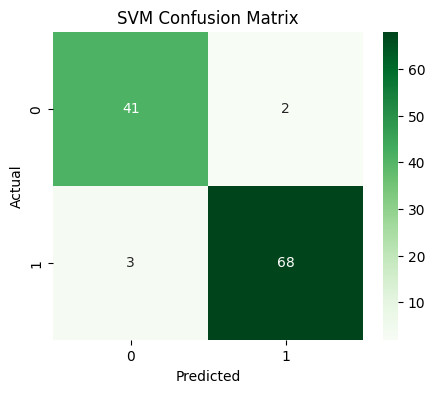

In [8]:
cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [9]:
parameters = {
    "n_neighbors":[3,5,7,9,11]
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    parameters,
    cv=5
)

grid_knn.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_knn.best_params_)

print("Best Accuracy:", grid_knn.best_score_)

Best Parameters: {'n_neighbors': 5}
Best Accuracy: 0.9604395604395606


In [10]:
parameters = {
    "C":[0.1,1,10],
    "kernel":["linear","rbf"],
    "gamma":["scale","auto"]
}

grid_svm = GridSearchCV(
    SVC(),
    parameters,
    cv=5
)

grid_svm.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_svm.best_params_)

print("Best Accuracy:", grid_svm.best_score_)

Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best Accuracy: 0.9758241758241759


In [11]:
results = pd.DataFrame({
    "Model":["KNN","Linear SVM"],
    "Accuracy":[
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, svm_pred)
    ]
})

print(results)

        Model  Accuracy
0         KNN  0.947368
1  Linear SVM  0.956140


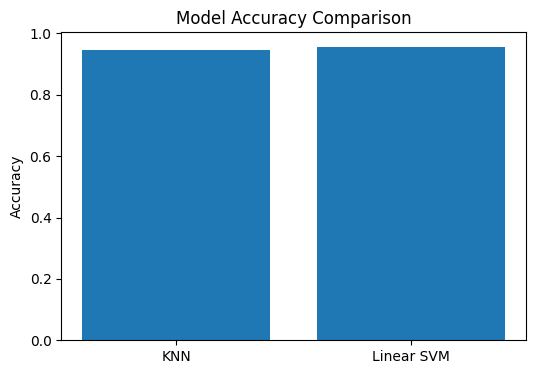

In [12]:
plt.figure(figsize=(6,4))

plt.bar(results["Model"], results["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()